# Point Cloud Rasterization to Multi-Channel 2D Grid

This notebook converts LiDAR point cloud data (.las files) into multi-channel 2D raster grids with various statistical channels including:
- Density (point count per pixel)
- Z-axis statistics (min, max, mean, range, percentiles)
- HAG (Height Above Ground) statistics
- HAG band counts

**Features:**
- Multi-channel raster output
- Configurable parameters for processing
- Various visualization options
- Export to PNG, NPY, and metadata formats

## 📋 Configuration Parameters

**Adjust these parameters as needed for your processing:**

In [23]:
# ============================================================================
# CONFIGURATION PARAMETERS - ADJUST THESE VALUES
# ============================================================================

# Input/Output Paths
INPUT_LAS = '../../../output/scans_test_optimized_1m.las'  # Input LAS file path
OUTPUT_DIR = '../../../output/rasterization_result_notebook'  # Output directory

# Grid Parameters
IMAGE_SIZE = 320      # Target image size (square pixels)
PIXEL_SIZE = 0.125    # Pixel size in meters
AREA_SIZE = 40.0      # Target area coverage in meters (for reference)

# Processing Options
NORMALIZE = True      # Normalize channels (except density) to 0-1 range
MIN_DENSITY = 10      # Mask pixels with density < this value in plots
HAG_SIGMA = 0.0       # Gaussian blur sigma for HAG-derived maps (0 = no blur)

# HAG Band Parameters (single band)
HAG_BAND_LOW = 0.2    # HAG band lower bound in meters
HAG_BAND_HIGH = 1.5   # HAG band upper bound in meters

# HAG Multiband Parameters (low/mid/high)
HAG_B1 = 0.4          # First cutpoint: low→mid (meters)
HAG_B2 = 1.4          # Second cutpoint: mid→high (meters)

# Output Options
SAVE_NPY = True                    # Save multi-channel array as .npy
SAVE_METADATA = True               # Save metadata JSON
SAVE_CHANNEL_PNGS = True           # Save individual channel PNGs
SAVE_RGB_COMPOSITE = True          # Save RGB composite image

# Visualization Options
VISUALIZE_SPAN = True              # Create density + Z span visualization
PLOT_Z_PERCENTILES = True          # Export plots for all Z percentile channels
USE_LOG_SCALE_Z = True             # Use logarithmic scale for Z percentile plots
PLOT_HAG_CHANNELS = True           # Export plots for HAG channels
PLOT_HAG_MULTIBAND = True          # Export HAG multiband RGB composite
COMPARE_DENSITY_HAG = True         # Create density vs HAG high comparison
PLOT_DENSITY_HISTOGRAM = False     # Create density histogram
PLOT_Z_HISTOGRAM = False           # Create Z-axis histogram

# Histogram Parameters
DENSITY_HISTOGRAM_BINS = 50        # Number of bins for density histogram
Z_HISTOGRAM_BINS = 100             # Number of bins for Z histogram

print("✓ Configuration loaded successfully")
print(f"  Input file: {INPUT_LAS}")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  Grid size: {IMAGE_SIZE}x{IMAGE_SIZE} pixels")
print(f"  Pixel size: {PIXEL_SIZE} m/pixel")
print(f"  Log scale for Z plots: {USE_LOG_SCALE_Z}")

✓ Configuration loaded successfully
  Input file: ../../../output/scans_test_optimized_1m.las
  Output directory: ../../../output/rasterization_result_notebook
  Grid size: 320x320 pixels
  Pixel size: 0.125 m/pixel
  Log scale for Z plots: True


## 📦 Import Required Libraries

In [24]:
import numpy as np
import laspy
import cv2
import os
import json
from pathlib import Path
from typing import Tuple, Dict, List, Optional
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy import ndimage
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib to display plots inline
%matplotlib inline

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 🛠️ Helper Functions

In [25]:
def _apply_optional_blur(img: np.ndarray, sigma: float) -> np.ndarray:
    """Apply Gaussian blur to image if sigma > 0."""
    if sigma is None or sigma <= 0:
        return img
    k = int(max(3, (int(round(sigma * 6)) | 1)))
    return cv2.GaussianBlur(img, (k, k), sigmaX=sigma, sigmaY=sigma, borderType=cv2.BORDER_REPLICATE)


def _norm01(x: np.ndarray) -> np.ndarray:
    """Normalize array to 0-1 range."""
    x = x.astype(float)
    mn, mx = float(x.min()), float(x.max())
    if mx <= mn:
        return np.zeros_like(x, dtype=float)
    return (x - mn) / (mx - mn)


def apply_log_transform(data: np.ndarray, min_density: float = 0) -> np.ndarray:
    """Apply logarithmic transformation to data for better visualization.
    
    Args:
        data: Input data array
        min_density: Minimum density threshold to apply transformation
    
    Returns:
        Log-transformed data
    """
    data_copy = data.copy()
    mask = data_copy > 0
    if min_density > 0:
        mask = mask & (data_copy >= min_density)
    
    result = np.zeros_like(data_copy)
    if np.any(mask):
        result[mask] = np.log1p(data_copy[mask])  # log1p = log(1 + x) to handle values near 0
    return result

print("✓ Helper functions defined")

✓ Helper functions defined


## 🏗️ PointCloudRasterizer Class

This class handles all the point cloud processing and rasterization operations.

In [26]:
# Due to the length of the class, it will be loaded from the original Python file
# This allows you to maintain a single source of truth for the core logic

import sys
sys.path.append('../')

# Import the rasterizer class from the original script
exec(open('pointcloud_rasterization.py').read().split('if __name__')[0])

print("✓ PointCloudRasterizer class loaded")

✓ PointCloudRasterizer class loaded


## 🚀 Run Rasterization

Execute the point cloud rasterization with your configured parameters.

In [27]:
# Initialize rasterizer
rasterizer = PointCloudRasterizer(
    image_size=IMAGE_SIZE,
    pixel_size=PIXEL_SIZE,
    area_size=AREA_SIZE
)

# Load point cloud
points, point_meta = rasterizer.load_pointcloud(INPUT_LAS)

# Rasterize to multi-channel grid
grid, meta = rasterizer.rasterize_multi_channel(points, normalize=NORMALIZE)

# Add HAG bands
grid = rasterizer.add_hag_band_count(grid, HAG_BAND_LOW, HAG_BAND_HIGH)
grid = rasterizer.add_hag_multiband_counts(grid, HAG_B1, HAG_B2)

# Normalize if requested (except density)
if NORMALIZE:
    print("  Normalizing channels (except density)...")
    for c in range(1, grid.shape[2]):
        ch = grid[:,:,c]
        mn, mx = float(ch.min()), float(ch.max())
        if mx > mn:
            grid[:,:,c] = (ch - mn) / (mx - mn)
    meta['normalized'] = True
    print("  Note: density channel kept as raw count")
else:
    meta['normalized'] = False

# Resize to target size
grid = rasterizer.resize_to_target(grid, IMAGE_SIZE)
meta['resized_to'] = int(IMAGE_SIZE)

print("\n✓ Rasterization complete!")

Rasterizer Configuration:
  Image size: 320×320 px
  Pixel size: 0.125 m/pixel
  Area coverage (target): 40.0×40.0 m

Loading point cloud: ../../../output/scans_test_optimized_1m.las
  Points: 10,762,684
  X range: -9.00 – 42.99 m
  Y range: -5.00 – 50.49 m
  Z range: -5.83 – 10.02 m

Rasterizing to multi-channel grid...
  Grid size: 416×444 px (184,704 total)
  Coverage: 52.00×55.50 m
  Computing density...
  Computing z_min/z_max/z_range/z_mean ...
  Computing HAG (height above ground) ...
  Computing Z percentiles per pixel ...
  Computing HAG percentiles per pixel ...
  ✓ Created 22-channel grid: 444×416×22
  Normalizing channels (except density)...
  Note: density channel kept as raw count
Resizing 444×416 → 320×320 ...

✓ Rasterization complete!


## 💾 Save Outputs

Save the generated raster data and visualizations.

In [28]:
# Create output directory
out_dir = Path(OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)
base = Path(INPUT_LAS).stem
out_base = out_dir / f"{base}_raster"

print(f"\nSaving outputs to: {out_dir}")

# Save channel PNGs
if SAVE_CHANNEL_PNGS:
    rasterizer.save_channels_png(
        grid, str(out_dir), f"{base}_raster", meta['channel_names'],
        min_density=MIN_DENSITY, blur_sigma=HAG_SIGMA
    )

# Save RGB composite
if SAVE_RGB_COMPOSITE:
    rasterizer.create_rgb_composite(
        grid, channels=(0,4,5), 
        out_path=out_dir / f"{base}_rgb.png"
    )

# Save NPY and metadata
if SAVE_NPY:
    np.save(str(out_base) + ".npy", np.nan_to_num(grid, nan=0.0, posinf=0.0, neginf=0.0))
    print(f"Saved multi-channel array: {str(out_base)}.npy")

if SAVE_METADATA or SAVE_NPY:
    with open(str(out_base) + "_metadata.json", 'w') as f:
        json.dump(meta, f, indent=2)
    print(f"Saved metadata: {str(out_base)}_metadata.json")

print("\n✓ Outputs saved successfully!")


Saving outputs to: ../../../output/rasterization_result_notebook
Saved 22 channel PNGs to ../../../output/rasterization_result_notebook/scans_test_optimized_1m_raster_channels
Saved RGB composite: ../../../output/rasterization_result_notebook/scans_test_optimized_1m_rgb.png
Saved multi-channel array: ../../../output/rasterization_result_notebook/scans_test_optimized_1m_raster.npy
Saved metadata: ../../../output/rasterization_result_notebook/scans_test_optimized_1m_raster_metadata.json

✓ Outputs saved successfully!


## 📊 Visualizations

Create various visualizations of the rasterized data.

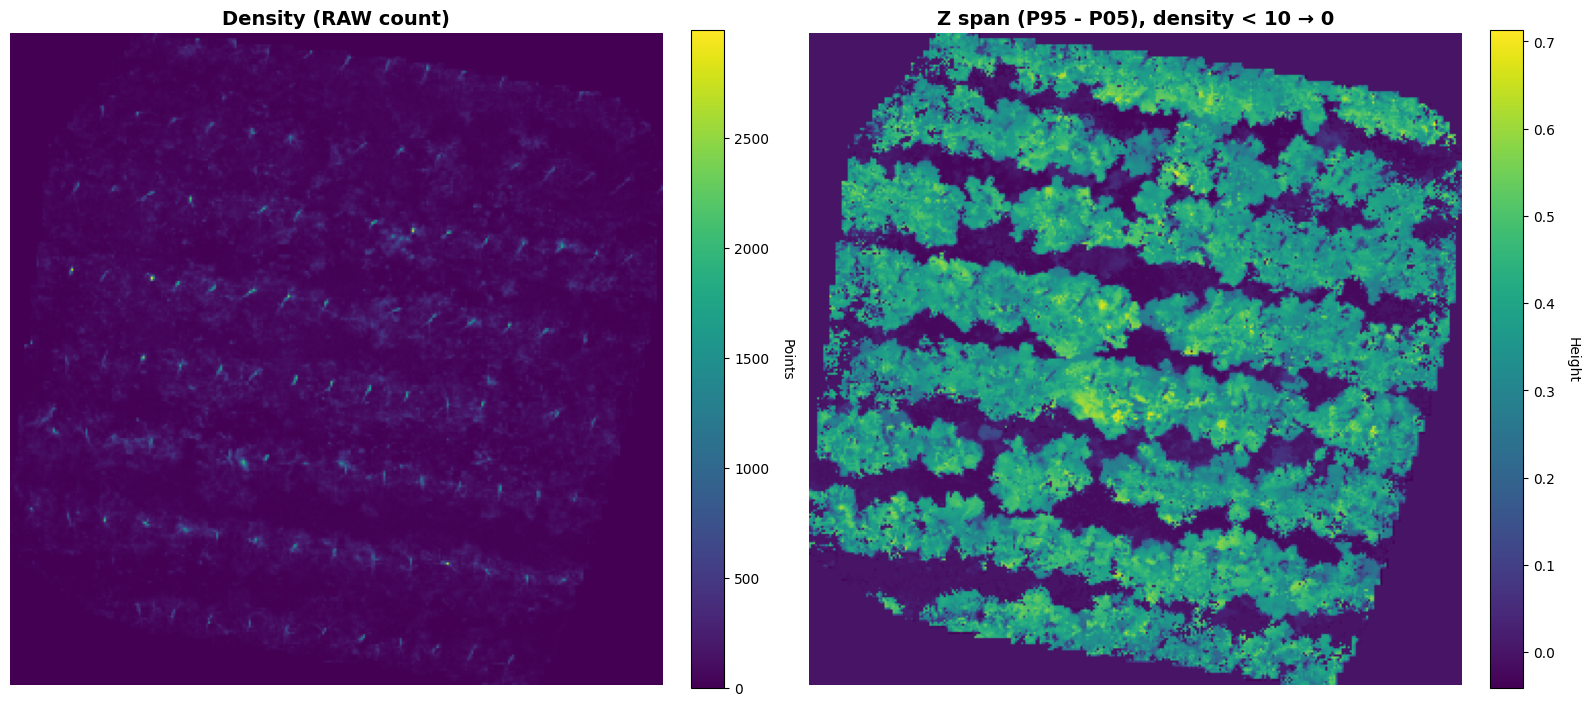

Saved visualization: ../../../output/rasterization_result_notebook/scans_test_optimized_1m_percentile_span.png


In [29]:
# Density + Z span visualization
if VISUALIZE_SPAN:
    density = np.nan_to_num(grid[:,:,0], nan=0.0)
    ch_names = meta['channel_names']
    p95 = grid[:,:,ch_names.index('z_p95')]
    p05 = grid[:,:,ch_names.index('z_p05')]
    span = np.nan_to_num(p95, nan=0.0) - np.nan_to_num(p05, nan=0.0)
    span[density < MIN_DENSITY] = 0.0

    fig, axes = plt.subplots(1, 2, figsize=(16,7))
    im0 = axes[0].imshow(density, cmap='viridis')
    axes[0].set_title('Density (RAW count)', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    c0 = plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    c0.set_label('Points', rotation=270, labelpad=18)

    im1 = axes[1].imshow(span, cmap='viridis')
    title = f'Z span (P95 - P05), density < {MIN_DENSITY} → 0'
    axes[1].set_title(title, fontsize=14, fontweight='bold')
    axes[1].axis('off')
    c1 = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    unit = '' if meta.get('normalized', True) else ' (m)'
    c1.set_label('Height'+unit, rotation=270, labelpad=18)

    plt.tight_layout()
    vis_path = out_dir / f"{base}_percentile_span.png"
    plt.savefig(str(vis_path), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved visualization: {vis_path}")

In [30]:
# Z percentile plots with optional log scale
if PLOT_Z_PERCENTILES:
    z_channels = [n for n in meta['channel_names'] if n.startswith('z_p')]
    scale_text = "(LOG SCALE)" if USE_LOG_SCALE_Z else ""
    print(f"\nCreating {len(z_channels)} Z percentile plots {scale_text}...")
    
    for name in z_channels:
        # Get channel data
        ch_idx = meta['channel_names'].index(name)
        data = np.nan_to_num(grid[:,:,ch_idx], nan=0.0)
        density = np.nan_to_num(grid[:,:,0], nan=0.0)
        
        # Apply density mask
        data[density < MIN_DENSITY] = 0.0
        
        # Apply log transformation if enabled
        if USE_LOG_SCALE_Z:
            data = apply_log_transform(data, min_density=0)
        
        # Create plot
        fig, ax = plt.subplots(figsize=(10, 8))
        im = ax.imshow(data, cmap='viridis')
        
        title = f"{name.upper()}"
        if USE_LOG_SCALE_Z:
            title += " (LOG SCALE)"
        if MIN_DENSITY > 0:
            title += f" | density < {MIN_DENSITY} → 0"
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.axis('off')
        
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar_label = 'log(Value)' if USE_LOG_SCALE_Z else 'Value'
        cbar.set_label(cbar_label, rotation=270, labelpad=20)
        
        plt.tight_layout()
        suffix = "_log" if USE_LOG_SCALE_Z else ""
        out_path = out_dir / f"{base}_{name}_pretty{suffix}.png"
        plt.savefig(str(out_path), dpi=150, bbox_inches='tight')
        plt.close()
    
    print(f"✓ Saved {len(z_channels)} Z percentile plots")


Creating 9 Z percentile plots (LOG SCALE)...
✓ Saved 9 Z percentile plots


In [31]:
# HAG channel plots
if PLOT_HAG_CHANNELS:
    hag_channels = ['hag_mean','hag_p05','hag_p10','hag_p25',
                    'hag_band_count','hag_low_count','hag_mid_count','hag_high_count']
    print(f"\nCreating {len(hag_channels)} HAG channel plots...")
    for name in hag_channels:
        if name in meta['channel_names']:
            out_path = out_dir / f"{base}_{name}_pretty.png"
            label = 'Count' if 'count' in name else 'Value'
            PointCloudRasterizer._save_single_plot(
                grid, meta, name, out_path, 
                min_density=MIN_DENSITY, label=label, blur_sigma=HAG_SIGMA
            )


Creating 8 HAG channel plots...
Saved: ../../../output/rasterization_result_notebook/scans_test_optimized_1m_hag_mean_pretty.png
Saved: ../../../output/rasterization_result_notebook/scans_test_optimized_1m_hag_p05_pretty.png
Saved: ../../../output/rasterization_result_notebook/scans_test_optimized_1m_hag_p10_pretty.png
Saved: ../../../output/rasterization_result_notebook/scans_test_optimized_1m_hag_p25_pretty.png
Saved: ../../../output/rasterization_result_notebook/scans_test_optimized_1m_hag_band_count_pretty.png
Saved: ../../../output/rasterization_result_notebook/scans_test_optimized_1m_hag_low_count_pretty.png
Saved: ../../../output/rasterization_result_notebook/scans_test_optimized_1m_hag_mid_count_pretty.png
Saved: ../../../output/rasterization_result_notebook/scans_test_optimized_1m_hag_high_count_pretty.png


In [32]:
# HAG multiband RGB
if PLOT_HAG_MULTIBAND:
    rasterizer.save_hag_multiband_rgb(
        grid, meta, out_dir / f"{base}_hag_multiband_rgb.png",
        min_density=MIN_DENSITY, blur_sigma=HAG_SIGMA
    )

Saved HAG multiband RGB: ../../../output/rasterization_result_notebook/scans_test_optimized_1m_hag_multiband_rgb.png


In [33]:
# Density vs HAG comparison
if COMPARE_DENSITY_HAG:
    save_density_vs_hag_high(
        grid, meta, out_dir / f"{base}",
        min_density=MIN_DENSITY, overlay_alpha=0.65
    )

Saved comparison (side-by-side): ../../../output/rasterization_result_notebook/scans_test_optimized_1m_density_vs_hag_high_side_by_side.png
Saved comparison (overlay): ../../../output/rasterization_result_notebook/scans_test_optimized_1m_density_vs_hag_high_overlay.png


In [34]:
# Density histogram
if PLOT_DENSITY_HISTOGRAM:
    PointCloudRasterizer.save_density_histogram(
        grid, meta, out_dir / f"{base}_density_histogram.png", 
        bins=DENSITY_HISTOGRAM_BINS
    )

In [35]:
# Z-axis histogram
if PLOT_Z_HISTOGRAM:
    PointCloudRasterizer.save_z_histogram(
        INPUT_LAS, out_dir / f"{base}_z_histogram.png", 
        bins=Z_HISTOGRAM_BINS
    )

## 📈 Summary and Results

Display summary information about the processing results.

In [36]:
print("\n" + "="*60)
print("PROCESSING COMPLETE!")
print("="*60)
print(f"\nInput file: {INPUT_LAS}")
print(f"Output directory: {out_dir}")
print(f"\nGrid dimensions: {meta['width']}×{meta['height']} pixels")
print(f"Number of channels: {meta['num_channels']}")
print(f"Normalized: {meta['normalized']}")
print(f"Log scale for Z plots: {USE_LOG_SCALE_Z}")
print(f"\nChannel names:")
for i, name in enumerate(meta['channel_names']):
    print(f"  [{i:2d}] {name}")

print(f"\n✓ All processing complete!")
print(f"✓ Results saved to: {out_dir}")


PROCESSING COMPLETE!

Input file: ../../../output/scans_test_optimized_1m.las
Output directory: ../../../output/rasterization_result_notebook

Grid dimensions: 416×444 pixels
Number of channels: 22
Normalized: True
Log scale for Z plots: True

Channel names:
  [ 0] density
  [ 1] z_max
  [ 2] z_min
  [ 3] z_range
  [ 4] z_mean
  [ 5] hag_mean
  [ 6] z_p01
  [ 7] z_p05
  [ 8] z_p10
  [ 9] z_p25
  [10] z_p50
  [11] z_p75
  [12] z_p90
  [13] z_p95
  [14] z_p99
  [15] hag_p05
  [16] hag_p10
  [17] hag_p25
  [18] hag_band_count
  [19] hag_low_count
  [20] hag_mid_count
  [21] hag_high_count

✓ All processing complete!
✓ Results saved to: ../../../output/rasterization_result_notebook


## 🎯 Draw Tree Positions from CSV

Load tree positions from CSV file and draw rectangles on the density visualization.

In [37]:
# Configuration for tree visualization
CSV_FILE = '../../../input/DBHaverage.csv'  # Path to CSV with tree positions
RECT_SIZE = 1.0  # Rectangle size in meters (half-width from center)
RECT_COLOR = (0, 255, 0)  # Green color for rectangles (BGR format)
RECT_THICKNESS = 2  # Line thickness in pixels

print("✓ Tree visualization configuration loaded")
print(f"  CSV file: {CSV_FILE}")
print(f"  Rectangle size: {RECT_SIZE} meters")

✓ Tree visualization configuration loaded
  CSV file: ../../../input/DBHaverage.csv
  Rectangle size: 1.0 meters


In [38]:
import pandas as pd

# Load CSV file
try:
    df_trees = pd.read_csv(CSV_FILE)
    print(f"✓ Loaded {len(df_trees)} tree records from CSV")
    print(f"  Columns: {list(df_trees.columns)}")
    
    # Remove rows with missing X or Y coordinates
    df_trees = df_trees.dropna(subset=['X', 'Y'])
    print(f"  Valid tree positions: {len(df_trees)}")
    
except Exception as e:
    print(f"✗ Error loading CSV: {e}")
    df_trees = None

✓ Loaded 71 tree records from CSV
  Columns: ['ID', 'X', 'Y', 'DBH', 'Value']
  Valid tree positions: 68


In [39]:
def world_to_pixel(x, y, meta):
    """
    Convert world coordinates (X, Y in meters) to pixel coordinates in the raster.
    
    Args:
        x, y: World coordinates in meters
        meta: Metadata dictionary containing coordinate transformation info
    
    Returns:
        (pixel_x, pixel_y): Pixel coordinates in the raster grid
    """
    # Get bounds from metadata
    x_min = meta.get('x_min', 0)
    y_min = meta.get('y_min', 0)
    pixel_size = meta.get('pixel_size', PIXEL_SIZE)
    
    # IMPORTANT: If grid was resized, we need to calculate the effective pixel size
    # Original grid size in pixels
    orig_width = meta.get('width', IMAGE_SIZE)
    orig_height = meta.get('height', IMAGE_SIZE)
    
    # Check if grid was resized to a different size
    resized_to = meta.get('resized_to', None)
    if resized_to and resized_to != orig_height:
        # Calculate the scale factor
        scale = resized_to / orig_height
        # Use current grid dimensions (after resize)
        current_width = int(orig_width * scale)
        current_height = resized_to
    else:
        current_width = orig_width
        current_height = orig_height
    
    # World size in meters
    x_max = meta.get('x_max', x_min + orig_width * pixel_size)
    y_max = meta.get('y_max', y_min + orig_height * pixel_size)
    world_width = x_max - x_min
    world_height = y_max - y_min
    
    # Calculate effective pixel size based on current grid dimensions
    effective_pixel_size_x = world_width / current_width
    effective_pixel_size_y = world_height / current_height
    
    # Convert world coordinates to pixel coordinates using effective pixel size
    pixel_x = int((x - x_min) / effective_pixel_size_x)
    pixel_y = int((y - y_min) / effective_pixel_size_y)
    
    # Note: Y axis is inverted in image coordinates
    # The raster has origin at top-left, but world coords have origin at bottom-left
    pixel_y = current_height - pixel_y - 1
    
    return pixel_x, pixel_y

print("✓ Coordinate conversion function defined")

✓ Coordinate conversion function defined



Drawing rectangles on density map...
  Effective pixel size: 0.1739 meters/pixel
  Rectangle half-size: 2 pixels (1.0 meters)

✓ Drawing complete:
  Trees drawn: 68
  Trees outside bounds: 0

✓ Saved visualization: ../../../output/rasterization_result_notebook/scans_test_optimized_1m_density_with_trees.png


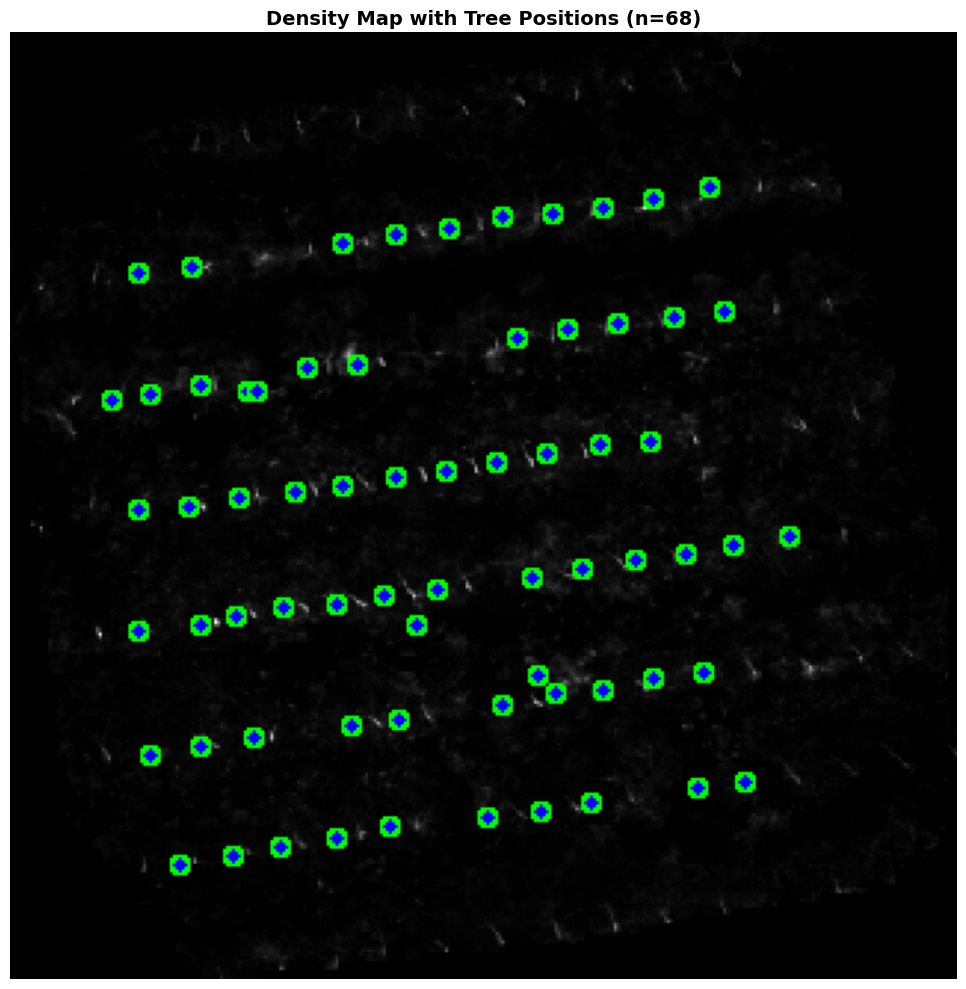

In [ ]:
if df_trees is not None:
    # Get density channel
    density = np.nan_to_num(grid[:,:,0], nan=0.0)
    
    # Convert to BGR image for drawing
    density_normalized = ((density - density.min()) / (density.max() - density.min()) * 255).astype(np.uint8)
    density_bgr = cv2.cvtColor(density_normalized, cv2.COLOR_GRAY2BGR)
    density_bgr_flipped = cv2.flip(density_bgr, 0)  # 0 = flip vertically (Y-axis)
        
    # Calculate effective pixel size (accounting for resize)
    orig_width = meta.get('width', IMAGE_SIZE)
    orig_height = meta.get('height', IMAGE_SIZE)
    resized_to = meta.get('resized_to', None)
    
    if resized_to and resized_to != orig_height:
        scale = resized_to / orig_height
        current_width = int(orig_width * scale)
    else:
        current_width = orig_width
    
    x_min = meta.get('x_min', 0)
    x_max = meta.get('x_max', 0)
    world_width = x_max - x_min
    effective_pixel_size = world_width / current_width
    
    # Convert rectangle size from meters to pixels using effective pixel size
    rect_half_size_pixels = int(RECT_SIZE *PIXEL_SIZE)
    
    print(f"\nDrawing rectangles on density map...")
    print(f"  Effective pixel size: {effective_pixel_size:.4f} meters/pixel")
    print(f"  Rectangle half-size: {rect_half_size_pixels} pixels ({RECT_SIZE} meters)")
    
    # Draw rectangles for each tree
    trees_drawn = 0
    trees_outside = 0
    
    for idx, row in df_trees.iterrows():
        x_world = row['X']
        y_world = row['Y']
        
        # Convert to pixel coordinates
        px, py = world_to_pixel(x_world, y_world, meta)
        
        # Apply 1.08x extension to X position
        px = int(px * 1.08)
        
        # Check if within bounds
        if 0 <= px < meta['width'] and 0 <= py < meta['height']:
            # Calculate rectangle corners
            x1 = max(0, px - rect_half_size_pixels)
            y1 = max(0, py - rect_half_size_pixels)
            x2 = min(meta['width'] - 1, px + rect_half_size_pixels)
            y2 = min(meta['height'] - 1, py + rect_half_size_pixels)
            
            # Draw rectangle
            cv2.rectangle(density_bgr_flipped, (x1, y1), (x2, y2), RECT_COLOR, RECT_THICKNESS)
            
            # Draw shifted circle (center point)
            cv2.circle(density_bgr_flipped, (px, py), 2, (255, 0, 0), -1)  # Blue dot
            
            trees_drawn += 1
        else:
            trees_outside += 1

    
    print(f"\n✓ Drawing complete:")
    print(f"  Trees drawn: {trees_drawn}")
    print(f"  Trees outside bounds: {trees_outside}")
    
    # Save the result
    output_path = out_dir / f"{base}_density_with_trees.png"
    cv2.imwrite(str(output_path), density_bgr_flipped)
    print(f"\n✓ Saved visualization: {output_path}")
    
    # Display the result
    plt.figure(figsize=(12, 10))
    plt.imshow(cv2.cvtColor(density_bgr_flipped, cv2.COLOR_BGR2RGB))
    plt.title(f'Density Map with Tree Positions (n={trees_drawn})', fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
else:
    print("✗ Cannot draw trees: CSV data not loaded")

In [41]:
# Print coordinate information for debugging
if df_trees is not None:
    print("\n" + "="*60)
    print("COORDINATE SYSTEM INFORMATION")
    print("="*60)
    print(f"\nRaster metadata:")
    print(f"  X range: {meta.get('x_min', 'N/A')} to {meta.get('x_max', 'N/A')} meters")
    print(f"  Y range: {meta.get('y_min', 'N/A')} to {meta.get('y_max', 'N/A')} meters")
    print(f"  Pixel size: {meta.get('pixel_size', PIXEL_SIZE)} meters")
    print(f"  Grid size: {meta['width']} × {meta['height']} pixels")
    
    print(f"\nTree positions (world coordinates):")
    print(f"  X range: {df_trees['X'].min():.2f} to {df_trees['X'].max():.2f} meters")
    print(f"  Y range: {df_trees['Y'].min():.2f} to {df_trees['Y'].max():.2f} meters")
    print(f"  Number of trees: {len(df_trees)}")
    
    print(f"\nFirst 5 tree positions:")
    for idx, row in df_trees.head().iterrows():
        px, py = world_to_pixel(row['X'], row['Y'], meta)
        print(f"  Tree {row['ID']}: ({row['X']:.2f}, {row['Y']:.2f}) m → pixel ({px}, {py})")


COORDINATE SYSTEM INFORMATION

Raster metadata:
  X range: -9.0 to 42.989999999999995 meters
  Y range: -5.0 to 50.489999999999995 meters
  Pixel size: 0.125 meters
  Grid size: 416 × 444 pixels

Tree positions (world coordinates):
  X range: -2.96 to 36.79 meters
  Y range: 1.74 to 41.32 meters
  Number of trees: 68

First 5 tree positions:
  Tree 1.0: (1.04, 1.74) m → pixel (57, 281)
  Tree 2.0: (4.05, 2.20) m → pixel (75, 278)
  Tree 3.0: (6.95, 2.76) m → pixel (91, 275)
  Tree 4.0: (10.20, 3.22) m → pixel (110, 272)
  Tree 5.0: (13.31, 3.92) m → pixel (128, 268)
